In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = torch.matmul(Q, K.transpose(-2, -1))
    scores = scores / math.sqrt(d_k)
    
    if mask is not None:
        scores = scores.masked_fill( mask == 0, float(-inf))
    
    weights = F.softmax(scores, dim= -1)
    output = torch.matmul( weights, V)

    return output, weights

batch, heads, seq, d_k = 2, 4, 6, 16
Q = torch.randn(batch, heads, seq, d_k)
K = torch.randn(batch, heads, seq, d_k)
V = torch.randn(batch, heads, seq, d_k)

out, weights = scaled_dot_product_attention(Q, K, V)
print(f"Attention output shape:  {out.shape}")
print(f"Attention weights shape: {weights.shape}")
print(f"Weights sum to 1: {weights[0, 0, 0].sum():.4f}")

Using device: mps
Attention output shape:  torch.Size([2, 4, 6, 16])
Attention weights shape: torch.Size([2, 4, 6, 6])
Weights sum to 1: 1.0000


- Read it as: 2 sentences × 4 heads × 6 tokens × 16 numbers per token.
- The shape[-1] is taking the last number as the input for d_k

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, \
            "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_Q = nn.Linear(d_model, d_model, bias = False)
        self.W_K = nn.Linear(d_model, d_model, bias = False)
        self.W_V = nn.Linear(d_model, d_model, bias = False)
        self.W_O = nn.Linear(d_model, d_model, bias = False)

    def split_heads(self, x):
        batch, seq, d_model = x.shape
        x = x.view(batch, seq, self.num_heads, self.d_k)
        return x.transpose(1,2)

    def forward(self, Q, K, V, mask= None):
        batch = Q.shape[0]

        Q = self.W_Q(Q)
        K = self.W_K(K)
        V = self.W_V(V)

        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        attn_out, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        attn_out = attn_out.transpose(1,2)
        attn_out = attn_out.reshape(batch, -1, self.d_model)

        output = self.W_O(attn_out)

        return output, attn_weights

d_model, num_heads, seq_len = 128, 8, 10
mha     = MultiHeadAttention(d_model, num_heads).to(device)
x_test  = torch.randn(2, seq_len, d_model).to(device)

# Self-attention: Q = K = V = x
out, attn_w = mha(x_test, x_test, x_test)
print(f"\nMulti-Head Attention:")
print(f"  Input:          {x_test.shape}")
print(f"  Output:         {out.shape}")
print(f"  Attention maps: {attn_w.shape}  "
      f"(batch, heads, seq_q, seq_k)")


Multi-Head Attention:
  Input:          torch.Size([2, 10, 128])
  Output:         torch.Size([2, 10, 128])
  Attention maps: torch.Size([2, 8, 10, 10])  (batch, heads, seq_q, seq_k)


- attn_out = attn_out.reshape(batch, -1, self.d_model)
- (2, 10, 8, 16) → (2, 10, 128)     ← merge 8×16 back into 128

- `reshape(-1, d_model)` — the `-1` means "figure out this dimension automatically" = 10. The 8 heads × 16 dimensions get concatenated back into the original 128.

In [3]:
class PositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding from the original paper.
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_seq_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build the PE matrix once
        pe  = torch.zeros(max_seq_len, d_model)
        pos = torch.arange(0, max_seq_len).unsqueeze(1).float()
        # Denominator term
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * -(math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(pos * div)   # even dimensions
        pe[:, 1::2] = torch.cos(pos * div)   # odd dimensions

        pe = pe.unsqueeze(0)   # (1, max_seq_len, d_model) — broadcast over batch
        # Register as buffer — saved with model but not a parameter
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.shape[1], :]
        return self.dropout(x)

pe_layer = PositionalEncoding(d_model=64, max_seq_len=100)
pe_matrix = pe_layer.pe[0].numpy()  # (100, 64)

print(f"\nPositional Encoding matrix shape: {pe_matrix.shape}")



Positional Encoding matrix shape: (100, 64)


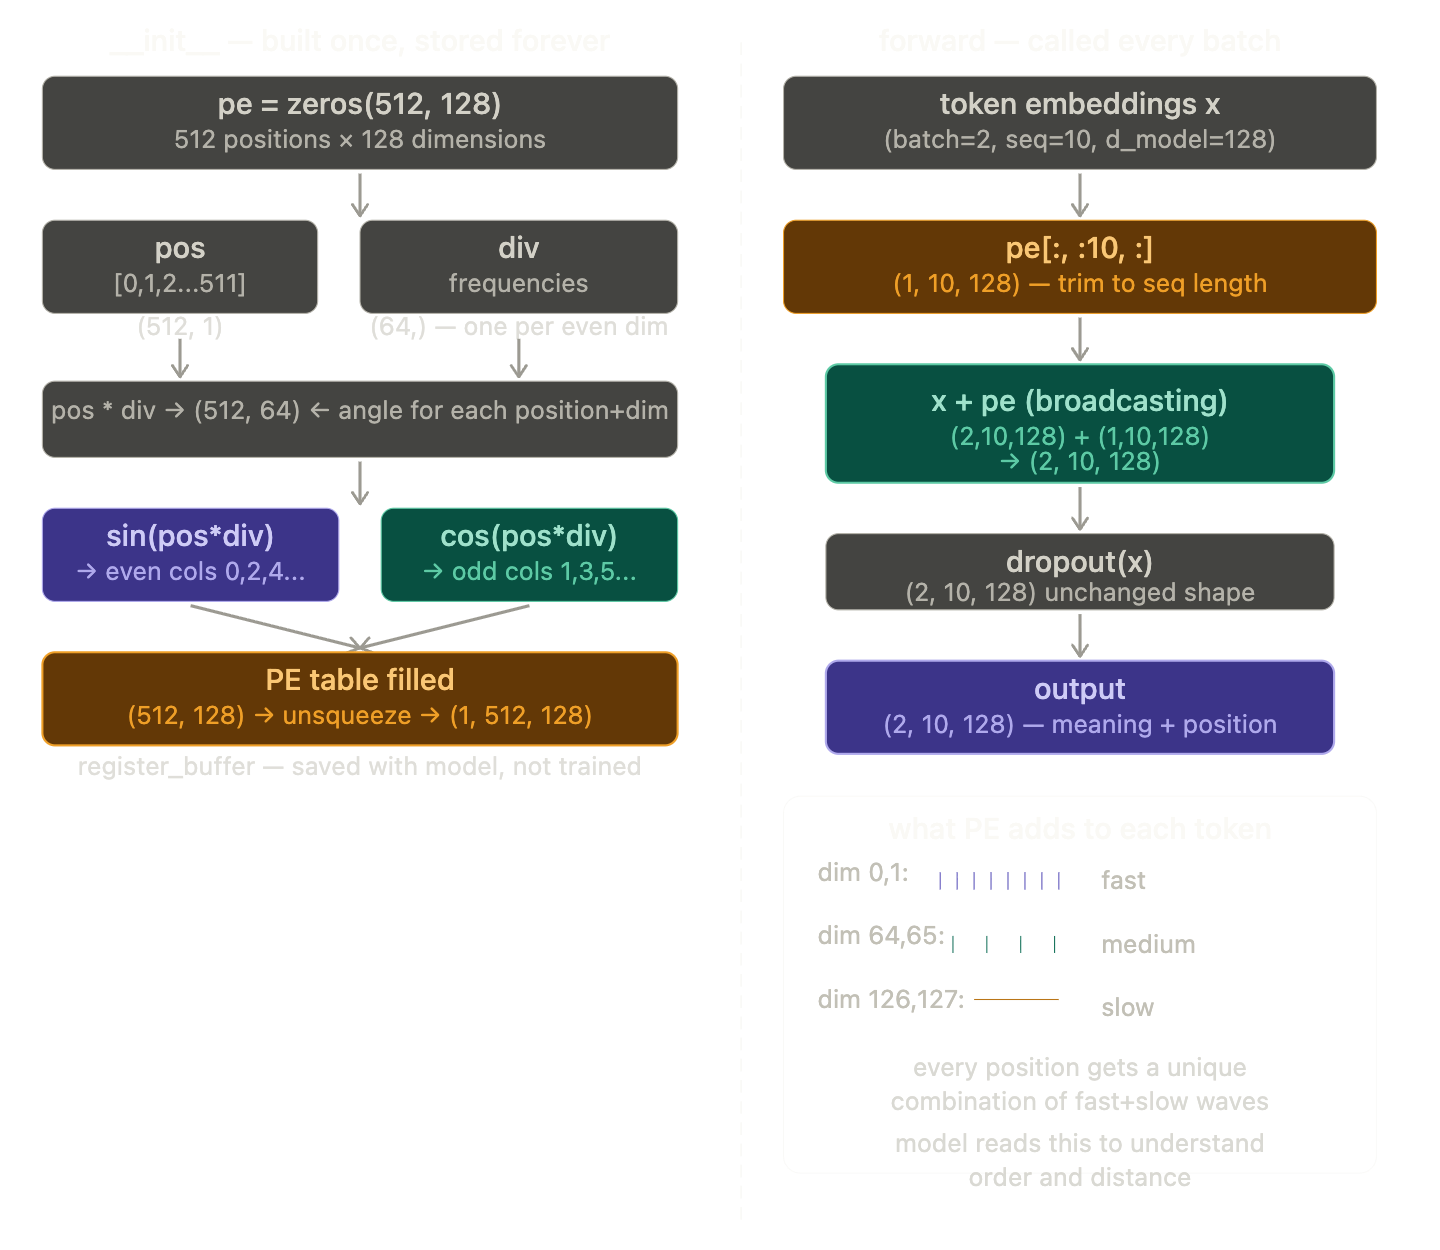

- The "Fast vs Slow" Intuition
- dim 0 (fast):  0.00 → 0.84 → 0.91 → 0.14 → ...   ← changes dramatically each step
- dim 6 (slow):  0.00 → 0.001 → 0.002 → 0.003 → ... ← barely moves between positions

- The fast dimensions distinguish nearby positions — "am I token 1 or token 2?" ; The slow dimensions distinguish distant positions — "am I in the first half or second half of the sentence?"

- Together they uniquely identify every position from 0 to 511 — like how seconds hand distinguishes nearby moments, hour hand distinguishes time of day.

In [4]:
class FeedForward(nn.Module):
    """
    Two linear transformations with ReLU in between.
    Inner dimension is typically 4x d_model.
    Applied independently to each position.
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),       # Expansion 
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),       # Compression
        )

    def forward(self, x):
        return self.net(x)

In [5]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout = 0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask= None):
        attn_out, attn_weights = self.attention(
            self.norm1(x), self.norm1(x), self.norm1(x), mask   # Q, K, V
        )
        x = x + self.dropout(attn_out)                          # ResNet
        x = x + self.dropout(self.ff(self.norm2(x)))            # Feed Forward with PreLN

        return x, attn_weights

class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_seq_len = 512, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_seq_len, dropout)
        self.blocks = nn.ModuleList(
            [
                EncoderBlock(d_model, num_heads, d_ff, dropout)
                for _ in range(num_layers)
            ]
        )
        self.norm = nn.LayerNorm(d_model)
        self.scale = math.sqrt(d_model)
    
    def forward(self, x, mask=None):
        x = self.embedding(x) * self.scale 
        x = self.pos_enc(x)

        all_attn_weights = []
        for block in self.blocks:
            x, attn_w = block(x, mask)
            all_attn_weights.append(attn_w)
        
        x = self.norm(x)
        return x, all_attn_weights

× √d_model scaling — before adding positional encoding, embeddings are multiplied by √128 ≈ 11.3. This is because embeddings are initialized with small values (~1) but PE values are in the range (-1, 1). Without scaling, PE would dominate the signal. Multiplying embeddings up makes them comparable in magnitude to PE.

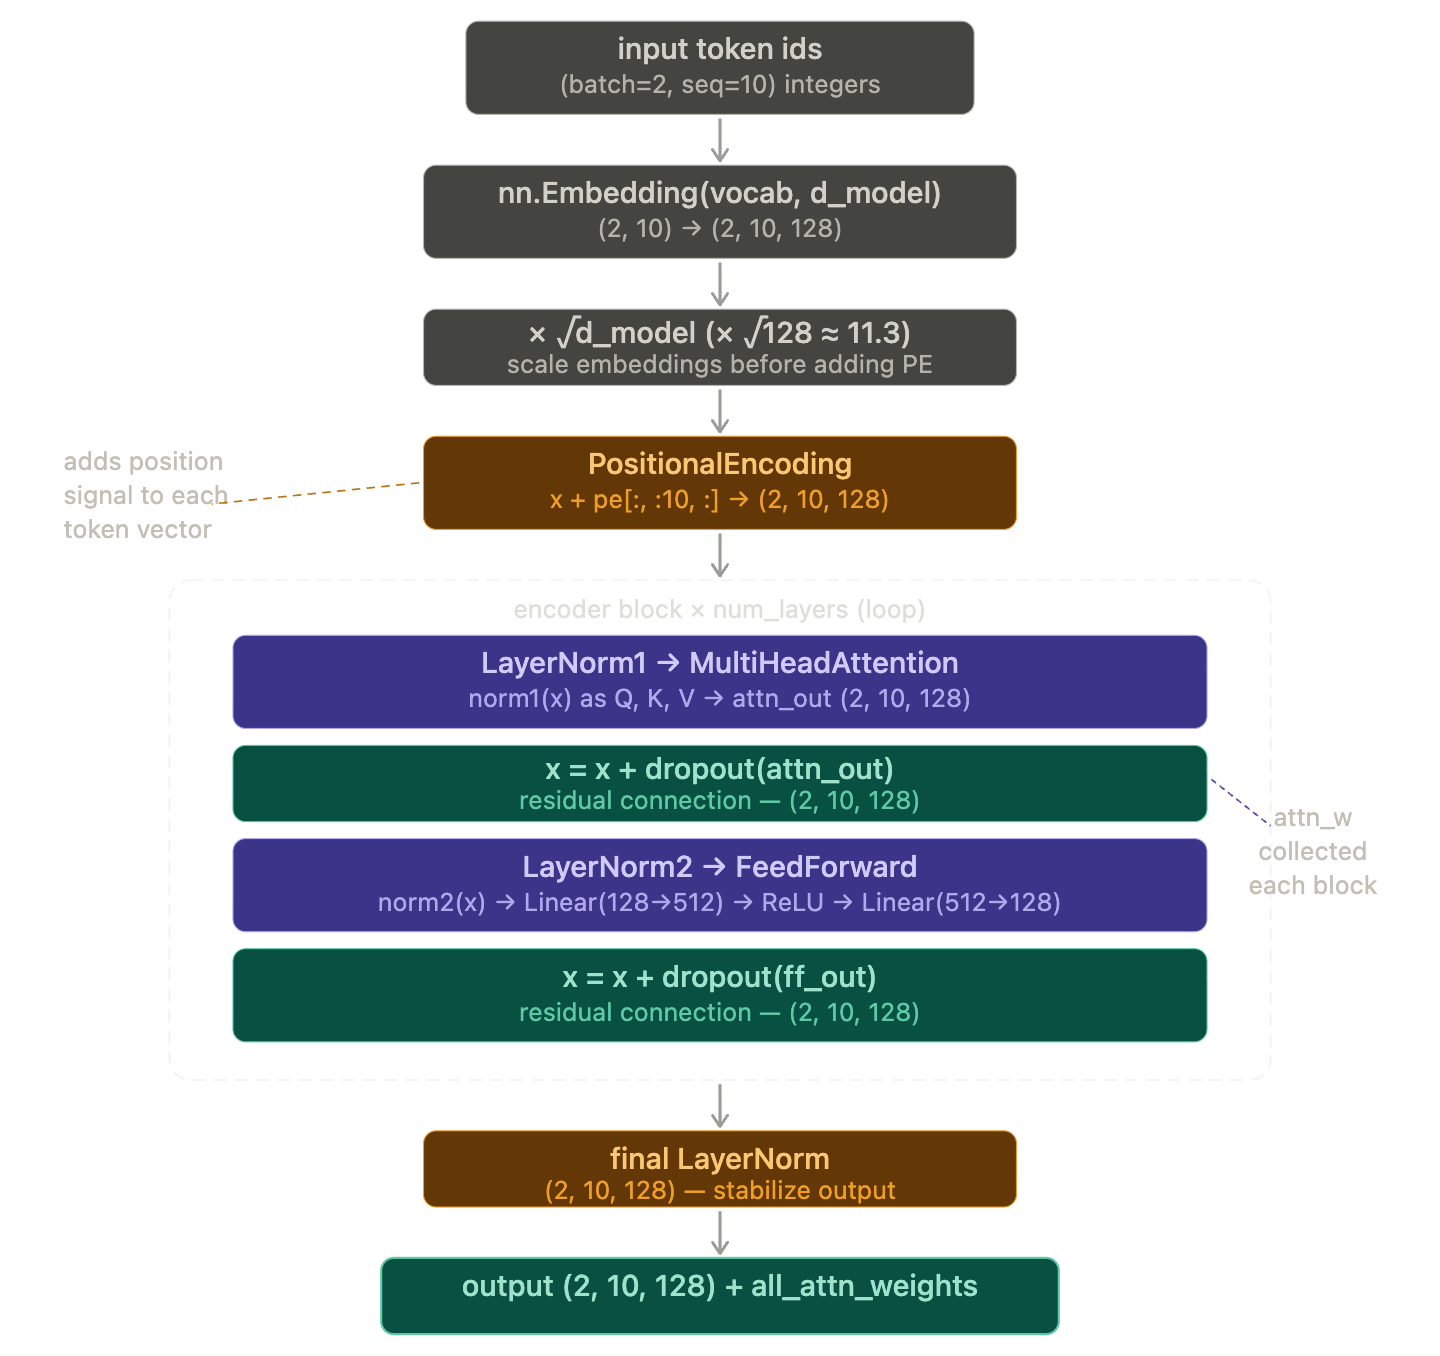

In [6]:
VOCAB_SIZE  = 1000
D_MODEL     = 128
NUM_HEADS   = 8
D_FF        = 512        # 4 * d_model
NUM_LAYERS  = 4
SEQ_LEN     = 20
BATCH_SIZE  = 2

encoder    = TransformerEncoder(
    VOCAB_SIZE, D_MODEL, NUM_HEADS,
    D_FF, NUM_LAYERS
).to(device)

x_tokens   = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN)).to(device)
enc_output, attn_weights = encoder(x_tokens)

print(f"\nFull Transformer Encoder:")
print(f"  Input tokens:   {x_tokens.shape}")
print(f"  Encoder output: {enc_output.shape}")
print(f"  Attention maps: {len(attn_weights)} layers × "
      f"{attn_weights[0].shape}")

total_params = sum(p.numel() for p in encoder.parameters())
print(f"  Total params:   {total_params:,}")


Full Transformer Encoder:
  Input tokens:   torch.Size([2, 20])
  Encoder output: torch.Size([2, 20, 128])
  Attention maps: 4 layers × torch.Size([2, 8, 20, 20])
  Total params:   919,296


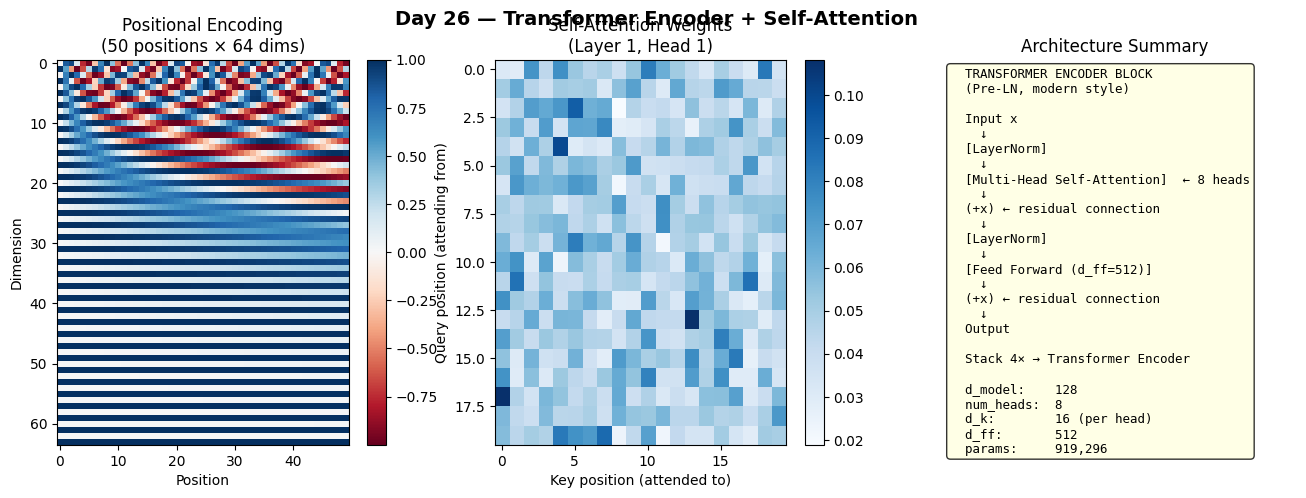

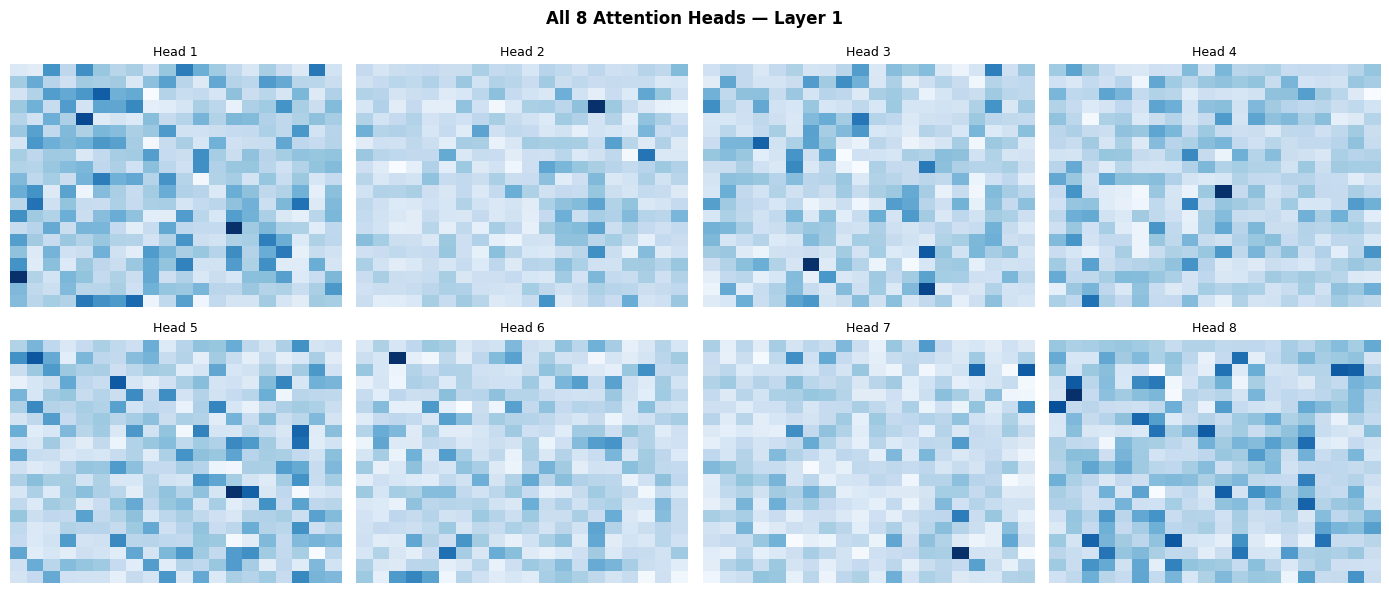

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Day 26 — Transformer Encoder + Self-Attention',
             fontsize=14, fontweight='bold')

# Positional encoding heatmap
im = axes[0].imshow(pe_matrix[:50, :64].T,
                    cmap='RdBu', aspect='auto')
axes[0].set_title('Positional Encoding\n(50 positions × 64 dims)')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Dimension')
plt.colorbar(im, ax=axes[0])

# Attention weights — Layer 1, Head 1
attn_viz = attn_weights[0][0, 0].detach().cpu().numpy()
im2 = axes[1].imshow(attn_viz, cmap='Blues', aspect='auto')
axes[1].set_title('Self-Attention Weights\n(Layer 1, Head 1)')
axes[1].set_xlabel('Key position (attended to)')
axes[1].set_ylabel('Query position (attending from)')
plt.colorbar(im2, ax=axes[1])

# Attention weights across all heads — Layer 1
fig_heads, ax_heads = plt.subplots(2, 4, figsize=(14, 6))
fig_heads.suptitle('All 8 Attention Heads — Layer 1',
                   fontsize=12, fontweight='bold')
for h in range(NUM_HEADS):
    row, col = h // 4, h % 4
    head_attn = attn_weights[0][0, h].detach().cpu().numpy()
    ax_heads[row, col].imshow(head_attn, cmap='Blues', aspect='auto')
    ax_heads[row, col].set_title(f'Head {h+1}', fontsize=9)
    ax_heads[row, col].axis('off')
plt.tight_layout()

# Architecture summary text
axes[2].axis('off')
summary = (
    "  TRANSFORMER ENCODER BLOCK\n"
    "  (Pre-LN, modern style)\n\n"
    "  Input x\n"
    "    ↓\n"
    "  [LayerNorm]\n"
    "    ↓\n"
    "  [Multi-Head Self-Attention]  ← 8 heads\n"
    "    ↓\n"
    "  (+x) ← residual connection\n"
    "    ↓\n"
    "  [LayerNorm]\n"
    "    ↓\n"
    "  [Feed Forward (d_ff=512)]\n"
    "    ↓\n"
    "  (+x) ← residual connection\n"
    "    ↓\n"
    "  Output\n\n"
    f"  Stack {NUM_LAYERS}× → Transformer Encoder\n\n"
    f"  d_model:    {D_MODEL}\n"
    f"  num_heads:  {NUM_HEADS}\n"
    f"  d_k:        {D_MODEL // NUM_HEADS} (per head)\n"
    f"  d_ff:       {D_FF}\n"
    f"  params:     {total_params:,}"
)
axes[2].text(0.05, 0.98, summary,
             transform=axes[2].transAxes,
             fontsize=9, verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round',
                       facecolor='lightyellow', alpha=0.8))
axes[2].set_title('Architecture Summary')

plt.tight_layout()
plt.show()